# QUWI Exploratory Data Analysis

This notebook explores the image-level characteristics and experimental composition of the QUWI dataset after integrity checking and writer-disjoint split construction.

## Goals

- Load and combine the image manifest and split metadata
- Summarize image dimensions, aspect ratios, and file sizes
- Compare Arabic and English handwriting samples
- Compare variable-text and same-text conditions
- Examine train, validation, and test distributions
- Identify unusual samples that may influence preprocessing
- Visualize representative handwriting pages

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

In [3]:
PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

MANIFEST_PATH = PROJECT_ROOT / "manifests" / "quwi_image_manifest.csv"
SPLIT_PATH = PROJECT_ROOT / "splits" / "quwi_writer_disjoint_split_seed42.csv"

manifest_df = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

merged_df = manifest_df.merge(
    split_df,
    on="filename",
    how="outer",
    validate="one_to_one",
    indicator=True,
    suffixes=("_manifest", "_split"),
)

print("Project root:", PROJECT_ROOT)
print("Manifest shape:", manifest_df.shape)
print("Split shape:", split_df.shape)
print("Merge status:", merged_df["_merge"].value_counts().to_dict())


Project root: /home/arijit/Documents/handwriting-cross-script-research
Manifest shape: (1900, 12)
Split shape: (1900, 7)
Merge status: {'both': 1900, 'left_only': 0, 'right_only': 0}


In [4]:
data_df = merged_df.loc[merged_df["_merge"] == "both"].copy()

writer_mismatches = data_df[
    data_df["writer_id"] != data_df["writer"]
]

page_mismatches = data_df[
    data_df["page_id_manifest"] != data_df["page_id_split"]
]

data_df["page_id"] = data_df["page_id_manifest"]
data_df["file_size_kb"] = data_df["file_size_bytes"] / 1024
data_df["file_size_mb"] = data_df["file_size_bytes"] / 1024**2

print("Combined rows:", len(data_df))
print("Writer mismatches:", len(writer_mismatches))
print("Page-ID mismatches:", len(page_mismatches))
print("Duplicate filenames:", data_df["filename"].duplicated().sum())
print("Missing values:", int(data_df.isna().sum().sum()))
print("Final columns:", len(data_df.columns))

Combined rows: 1900
Writer mismatches: 0
Page-ID mismatches: 0
Duplicate filenames: 0
Missing values: 0
Final columns: 22


In [5]:
numeric_summary = data_df[
    [
        "width",
        "height",
        "aspect_ratio",
        "file_size_kb",
    ]
].describe().T

display(numeric_summary.round(3))

,count,mean,std,min,25%,50%,75%,max
width,1900.0,2475.521,113.986,2083.000,2465.000,2471.000,2472.000,4967.000
height,1900.0,3367.107,206.826,944.000,3360.000,3371.000,3377.000,6731.000
aspect_ratio,1900.0,0.738,0.077,0.724,0.731,0.733,0.735,2.223
file_size_kb,1900.0,1236.260,493.172,430.080,866.533,1171.000,1552.785,6698.730


In [6]:
composition_table = (
    data_df.groupby(
        ["experiment_split", "language", "same_text"],
        observed=True,
    )
    .size()
    .rename("images")
    .reset_index()
)

display(composition_table)

,experiment_split,language,same_text,images
0,development_train,Arabic,0,226
1,development_train,Arabic,1,226
2,development_train,English,0,226
3,development_train,English,1,226
4,official_test,Arabic,0,193
5,official_test,Arabic,1,193
6,official_test,English,0,193
7,official_test,English,1,193
8,validation,Arabic,0,56
9,validation,Arabic,1,56


In [7]:
condition_summary = (
    data_df.groupby(
        ["language", "same_text"],
        observed=True,
    )
    .agg(
        images=("filename", "size"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median"),
    )
    .reset_index()
)

display(condition_summary.round(3))

,language,same_text,images,mean_width,mean_height,median_aspect_ratio,median_file_size_kb
0,Arabic,0,475,2475.175,3380.531,0.732,764.650
1,Arabic,1,475,2475.097,3362.297,0.733,1192.463
2,English,0,475,2475.520,3362.899,0.733,1102.644
3,English,1,475,2476.293,3362.703,0.734,1647.979


In [8]:
outlier_columns = [
    "width",
    "height",
    "aspect_ratio",
    "file_size_kb",
]

outlier_summary = []

for column in outlier_columns:
    q1 = data_df[column].quantile(0.25)
    q3 = data_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (data_df[column] < lower_bound)
        | (data_df[column] > upper_bound)
    ).sum()

    outlier_summary.append(
        {
            "feature": column,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_count),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df.round(3))

,feature,lower_bound,upper_bound,outlier_count
0,width,2454.500,2482.500,111
1,height,3334.500,3402.500,15
2,aspect_ratio,0.725,0.741,29
3,file_size_kb,-162.846,2582.163,10


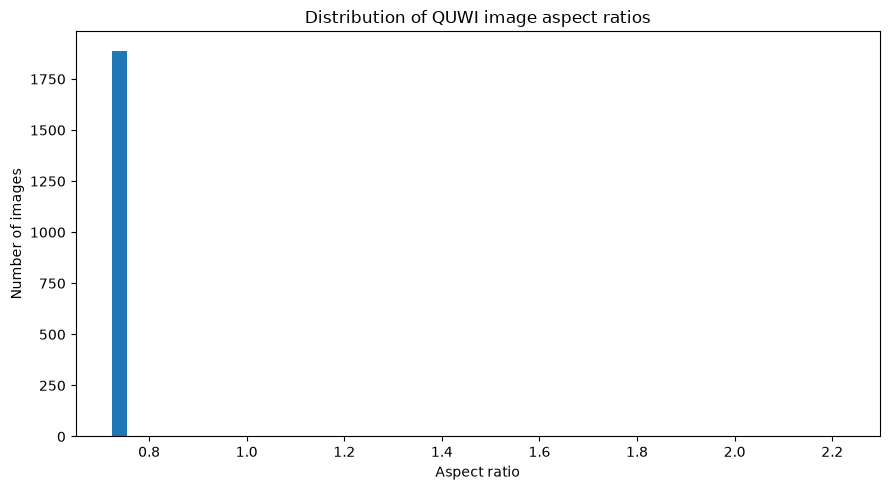

In [9]:
plt.figure(figsize=(9, 5))
plt.hist(data_df["aspect_ratio"], bins=50)
plt.xlabel("Aspect ratio")
plt.ylabel("Number of images")
plt.title("Distribution of QUWI image aspect ratios")
plt.tight_layout()
plt.show()

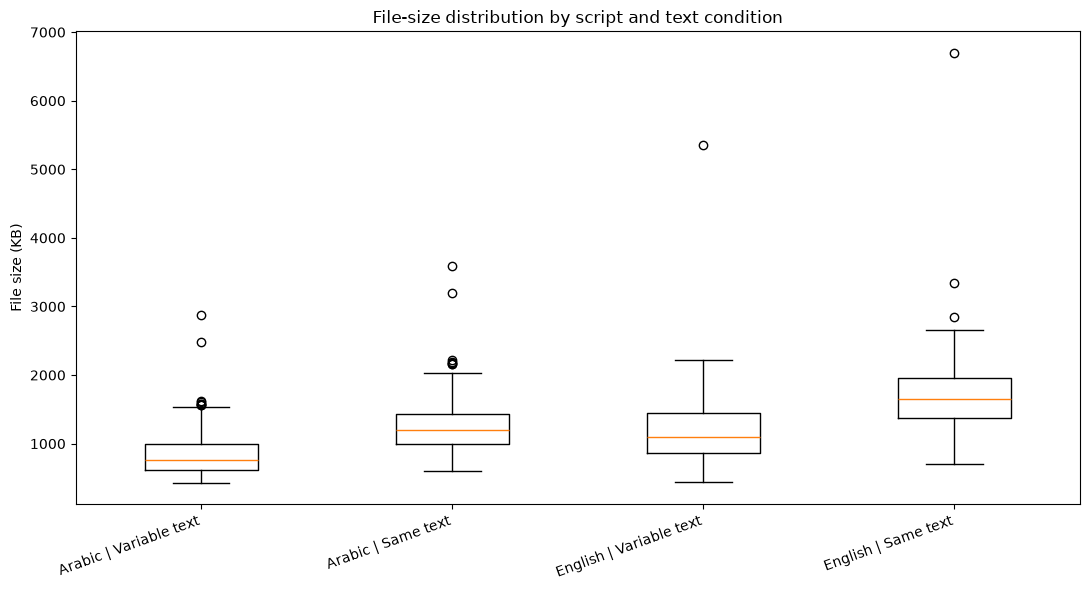

In [10]:
data_df["condition"] = (
    data_df["language"]
    + " | "
    + data_df["same_text"].map(
        {
            0: "Variable text",
            1: "Same text",
        }
    )
)

condition_order = [
    "Arabic | Variable text",
    "Arabic | Same text",
    "English | Variable text",
    "English | Same text",
]

file_size_groups = [
    data_df.loc[
        data_df["condition"] == condition,
        "file_size_kb",
    ]
    for condition in condition_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(
    file_size_groups,
    tick_labels=condition_order,
    showfliers=True,
)
plt.ylabel("File size (KB)")
plt.title("File-size distribution by script and text condition")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

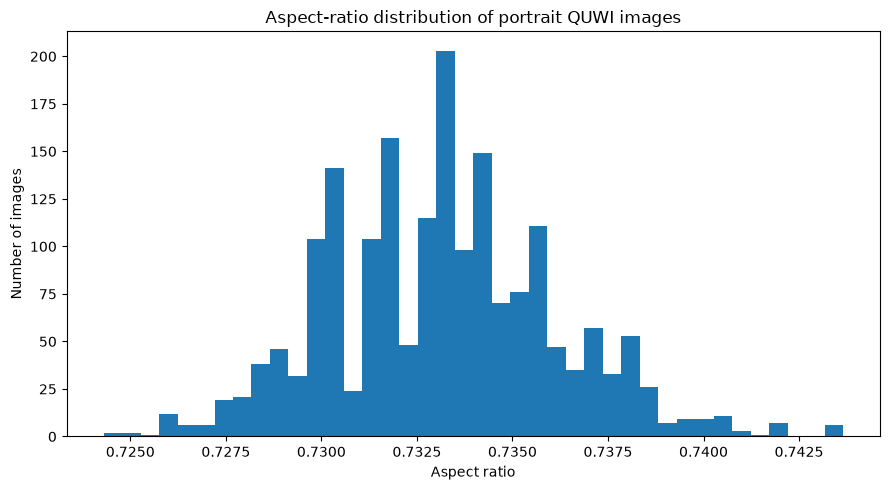

In [11]:
portrait_aspect_ratios = data_df.loc[
    data_df["aspect_ratio"] < 1,
    "aspect_ratio",
]

plt.figure(figsize=(9, 5))
plt.hist(portrait_aspect_ratios, bins=40)
plt.xlabel("Aspect ratio")
plt.ylabel("Number of images")
plt.title("Aspect-ratio distribution of portrait QUWI images")
plt.tight_layout()
plt.show()

In [12]:
extreme_aspect_ratio_df = (
    data_df.loc[
        data_df["aspect_ratio"] >= 1,
        [
            "filename",
            "writer",
            "page_id",
            "language",
            "same_text",
            "width",
            "height",
            "aspect_ratio",
            "experiment_split",
        ],
    ]
    .sort_values("aspect_ratio")
    .reset_index(drop=True)
)

display(extreme_aspect_ratio_df.round(3))

,filename,writer,page_id,language,same_text,width,height,aspect_ratio,experiment_split
0,0428_2.jpg,428,2,Arabic,1,2313,2201,1.051,official_test
1,0149_4.jpg,149,4,English,1,2438,2188,1.114,validation
2,0307_4.jpg,307,4,English,1,2477,2144,1.155,official_test
3,0428_4.jpg,428,4,English,1,2471,2129,1.161,official_test
4,0149_2.jpg,149,2,Arabic,1,2387,1905,1.253,validation
5,0428_3.jpg,428,3,English,0,2471,1961,1.260,official_test
6,0221_2.jpg,221,2,Arabic,1,2380,1161,2.050,development_train
7,0377_3.jpg,377,3,English,0,2483,1161,2.139,official_test
8,0164_2.jpg,164,2,Arabic,1,2324,1057,2.199,development_train
9,0307_3.jpg,307,3,English,0,2083,944,2.207,official_test


In [13]:
QUWI_ROOT = Path.home() / "Documents" / "Handwriting" / "QUWI"
IMAGE_DIR = QUWI_ROOT / "extracted" / "images"

sample_writer = 1

sample_writer_df = (
    data_df.loc[
        data_df["writer"] == sample_writer,
        [
            "filename",
            "page_id",
            "language",
            "same_text",
            "experiment_split",
        ],
    ]
    .sort_values("page_id")
    .reset_index(drop=True)
)

display(sample_writer_df)

,filename,page_id,language,same_text,experiment_split
0,0001_1.jpg,1,Arabic,0,development_train
1,0001_2.jpg,2,Arabic,1,development_train
2,0001_3.jpg,3,English,0,development_train
3,0001_4.jpg,4,English,1,development_train


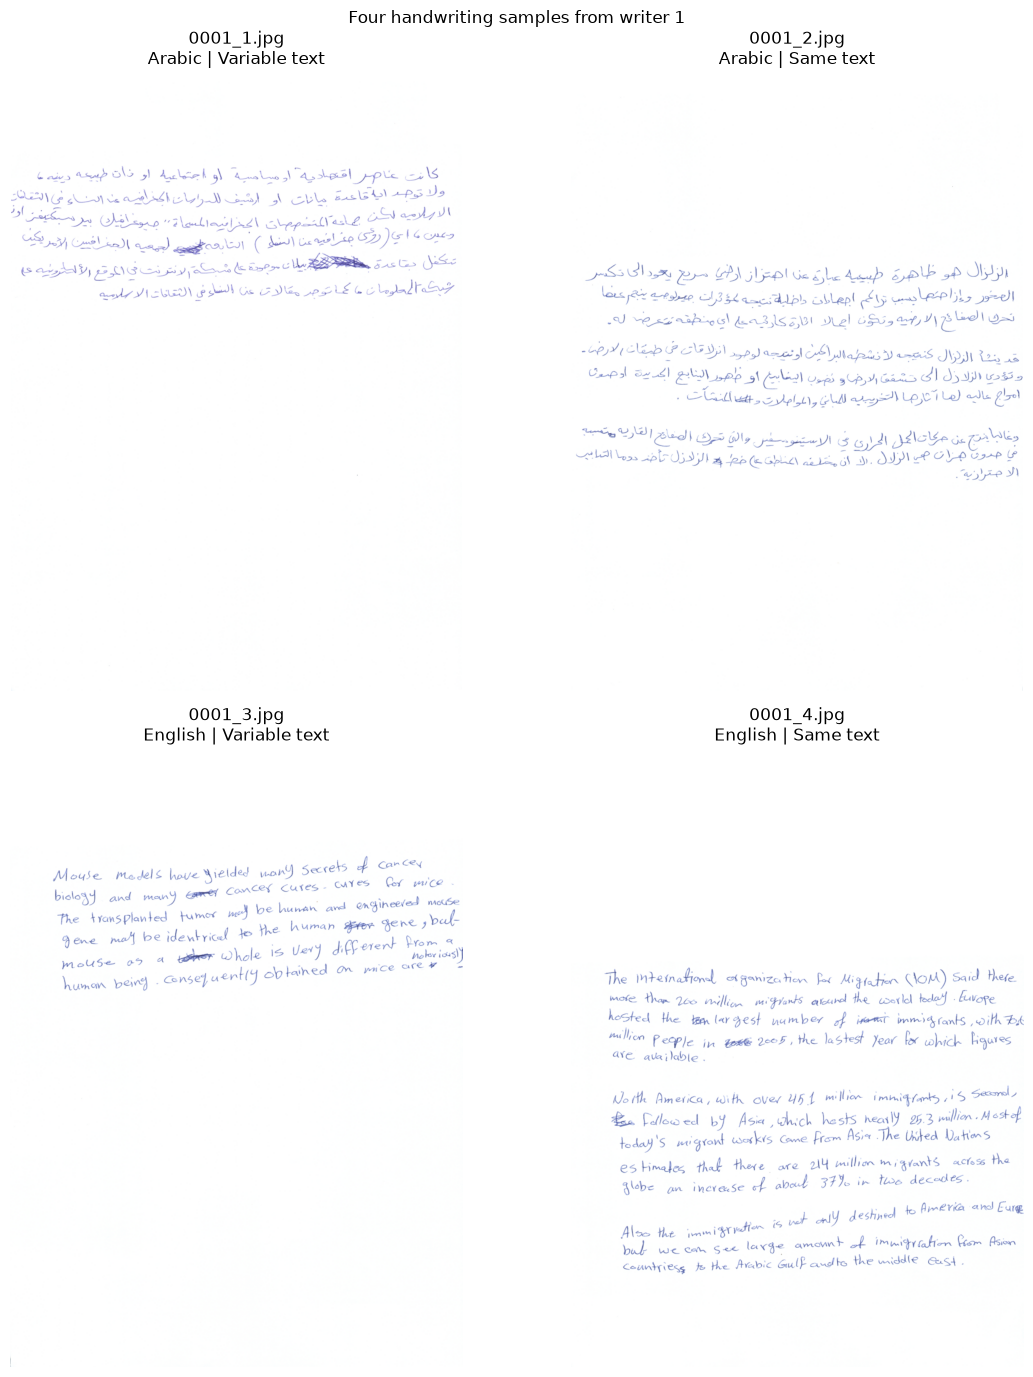

In [14]:
figure, axes = plt.subplots(2, 2, figsize=(12, 14))

for axis, row in zip(axes.flat, sample_writer_df.itertuples()):
    image_path = IMAGE_DIR / row.filename

    with Image.open(image_path) as image:
        preview = image.copy()
        preview.thumbnail((900, 1100))

    text_condition = (
        "Same text"
        if row.same_text == 1
        else "Variable text"
    )

    axis.imshow(preview)
    axis.set_title(
        f"{row.filename}\n{row.language} | {text_condition}"
    )
    axis.axis("off")

plt.suptitle(f"Four handwriting samples from writer {sample_writer}")
plt.tight_layout()
plt.show()

In [15]:
def estimate_image_statistics(image_path, max_size=512, threshold=200):
    with Image.open(image_path) as image:
        grayscale = image.convert("L")
        grayscale.thumbnail((max_size, max_size))
        pixels = np.asarray(grayscale, dtype=np.uint8)

    return {
        "mean_intensity": float(pixels.mean()),
        "dark_pixel_ratio": float((pixels < threshold).mean()),
    }


image_statistics = []

for filename in data_df["filename"]:
    statistics = estimate_image_statistics(IMAGE_DIR / filename)
    image_statistics.append(statistics)

statistics_df = pd.DataFrame(image_statistics)

data_df["mean_intensity"] = statistics_df["mean_intensity"].values
data_df["dark_pixel_ratio"] = statistics_df["dark_pixel_ratio"].values

print("Computed image statistics:", len(statistics_df))
print("Missing values:", int(statistics_df.isna().sum().sum()))

Computed image statistics: 1900
Missing values: 0


In [16]:
ink_summary = (
    data_df.groupby(
        ["language", "same_text"],
        observed=True,
    )
    .agg(
        images=("filename", "size"),
        mean_intensity=("mean_intensity", "mean"),
        median_intensity=("mean_intensity", "median"),
        mean_dark_pixel_ratio=("dark_pixel_ratio", "mean"),
        median_dark_pixel_ratio=("dark_pixel_ratio", "median"),
    )
    .reset_index()
)

display(ink_summary.round(4))

,language,same_text,images,mean_intensity,median_intensity,mean_dark_pixel_ratio,median_dark_pixel_ratio
0,Arabic,0,475,253.3208,253.4071,0.0121,0.0117
1,Arabic,1,475,252.1642,252.3886,0.0206,0.0190
2,English,0,475,253.0430,253.1665,0.0147,0.0141
3,English,1,475,251.1538,251.3786,0.0287,0.0273


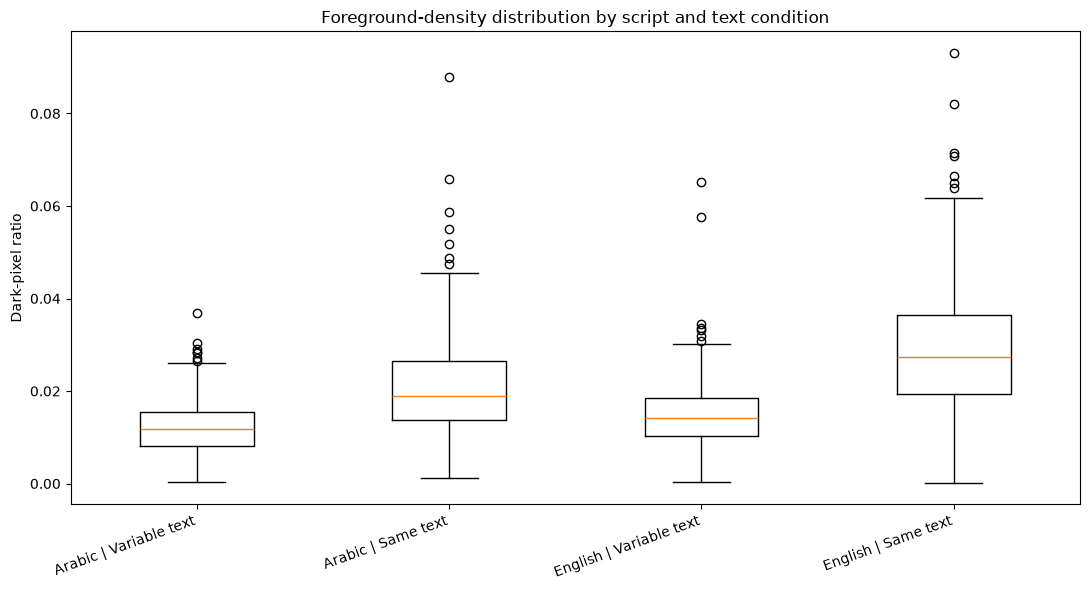

In [17]:
dark_ratio_groups = [
    data_df.loc[
        data_df["condition"] == condition,
        "dark_pixel_ratio",
    ]
    for condition in condition_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(
    dark_ratio_groups,
    tick_labels=condition_order,
    showfliers=True,
)
plt.ylabel("Dark-pixel ratio")
plt.title("Foreground-density distribution by script and text condition")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [18]:
density_columns = [
    "filename",
    "writer",
    "page_id",
    "language",
    "same_text",
    "dark_pixel_ratio",
    "mean_intensity",
    "experiment_split",
]

lowest_density_df = (
    data_df[density_columns]
    .nsmallest(10, "dark_pixel_ratio")
    .reset_index(drop=True)
)

highest_density_df = (
    data_df[density_columns]
    .nlargest(10, "dark_pixel_ratio")
    .reset_index(drop=True)
)

print("Lowest foreground-density samples")
display(lowest_density_df.round(4))

print("Highest foreground-density samples")
display(highest_density_df.round(4))

Lowest foreground-density samples


,filename,writer,page_id,language,same_text,dark_pixel_ratio,mean_intensity,experiment_split
0,0002_4.jpg,2,4,English,1,0.0002,253.3132,development_train
1,0367_3.jpg,367,3,English,0,0.0003,254.2702,official_test
2,0302_1.jpg,302,1,Arabic,0,0.0003,254.1712,official_test
3,0367_4.jpg,367,4,English,1,0.0003,253.7686,official_test
4,0212_4.jpg,212,4,English,1,0.0004,253.7784,development_train
5,0225_1.jpg,225,1,Arabic,0,0.0007,254.3171,development_train
6,0039_3.jpg,39,3,English,0,0.0007,254.3390,development_train
7,0160_1.jpg,160,1,Arabic,0,0.0010,254.0594,development_train
8,0367_2.jpg,367,2,Arabic,1,0.0012,253.8276,official_test
9,0410_1.jpg,410,1,Arabic,0,0.0018,254.1789,official_test


Highest foreground-density samples


,filename,writer,page_id,language,same_text,dark_pixel_ratio,mean_intensity,experiment_split
0,0244_4.jpg,244,4,English,1,0.0931,243.7546,development_train
1,0244_2.jpg,244,2,Arabic,1,0.0879,244.4750,development_train
2,0324_4.jpg,324,4,English,1,0.0820,244.2158,official_test
3,0421_4.jpg,421,4,English,1,0.0714,246.3918,official_test
4,0363_4.jpg,363,4,English,1,0.0709,246.5174,official_test
5,0086_4.jpg,86,4,English,1,0.0665,246.9428,development_train
6,0221_2.jpg,221,2,Arabic,1,0.0658,247.2311,development_train
7,0086_3.jpg,86,3,English,0,0.0653,247.1951,development_train
8,0221_4.jpg,221,4,English,1,0.0649,247.1033,development_train
9,0353_4.jpg,353,4,English,1,0.0640,247.0918,official_test


In [19]:
inspection_df = pd.concat(
    [
        data_df.nsmallest(5, "dark_pixel_ratio").assign(density_group="Lowest"),
        data_df.nlargest(5, "dark_pixel_ratio").assign(density_group="Highest"),
    ],
    ignore_index=True,
)

display(
    inspection_df[
        [
            "density_group",
            "filename",
            "language",
            "same_text",
            "dark_pixel_ratio",
            "experiment_split",
        ]
    ].round(4)
)

,density_group,filename,language,same_text,dark_pixel_ratio,experiment_split
0,Lowest,0002_4.jpg,English,1,0.0002,development_train
1,Lowest,0367_3.jpg,English,0,0.0003,official_test
2,Lowest,0302_1.jpg,Arabic,0,0.0003,official_test
3,Lowest,0367_4.jpg,English,1,0.0003,official_test
4,Lowest,0212_4.jpg,English,1,0.0004,development_train
5,Highest,0244_4.jpg,English,1,0.0931,development_train
6,Highest,0244_2.jpg,Arabic,1,0.0879,development_train
7,Highest,0324_4.jpg,English,1,0.0820,official_test
8,Highest,0421_4.jpg,English,1,0.0714,official_test
9,Highest,0363_4.jpg,English,1,0.0709,official_test


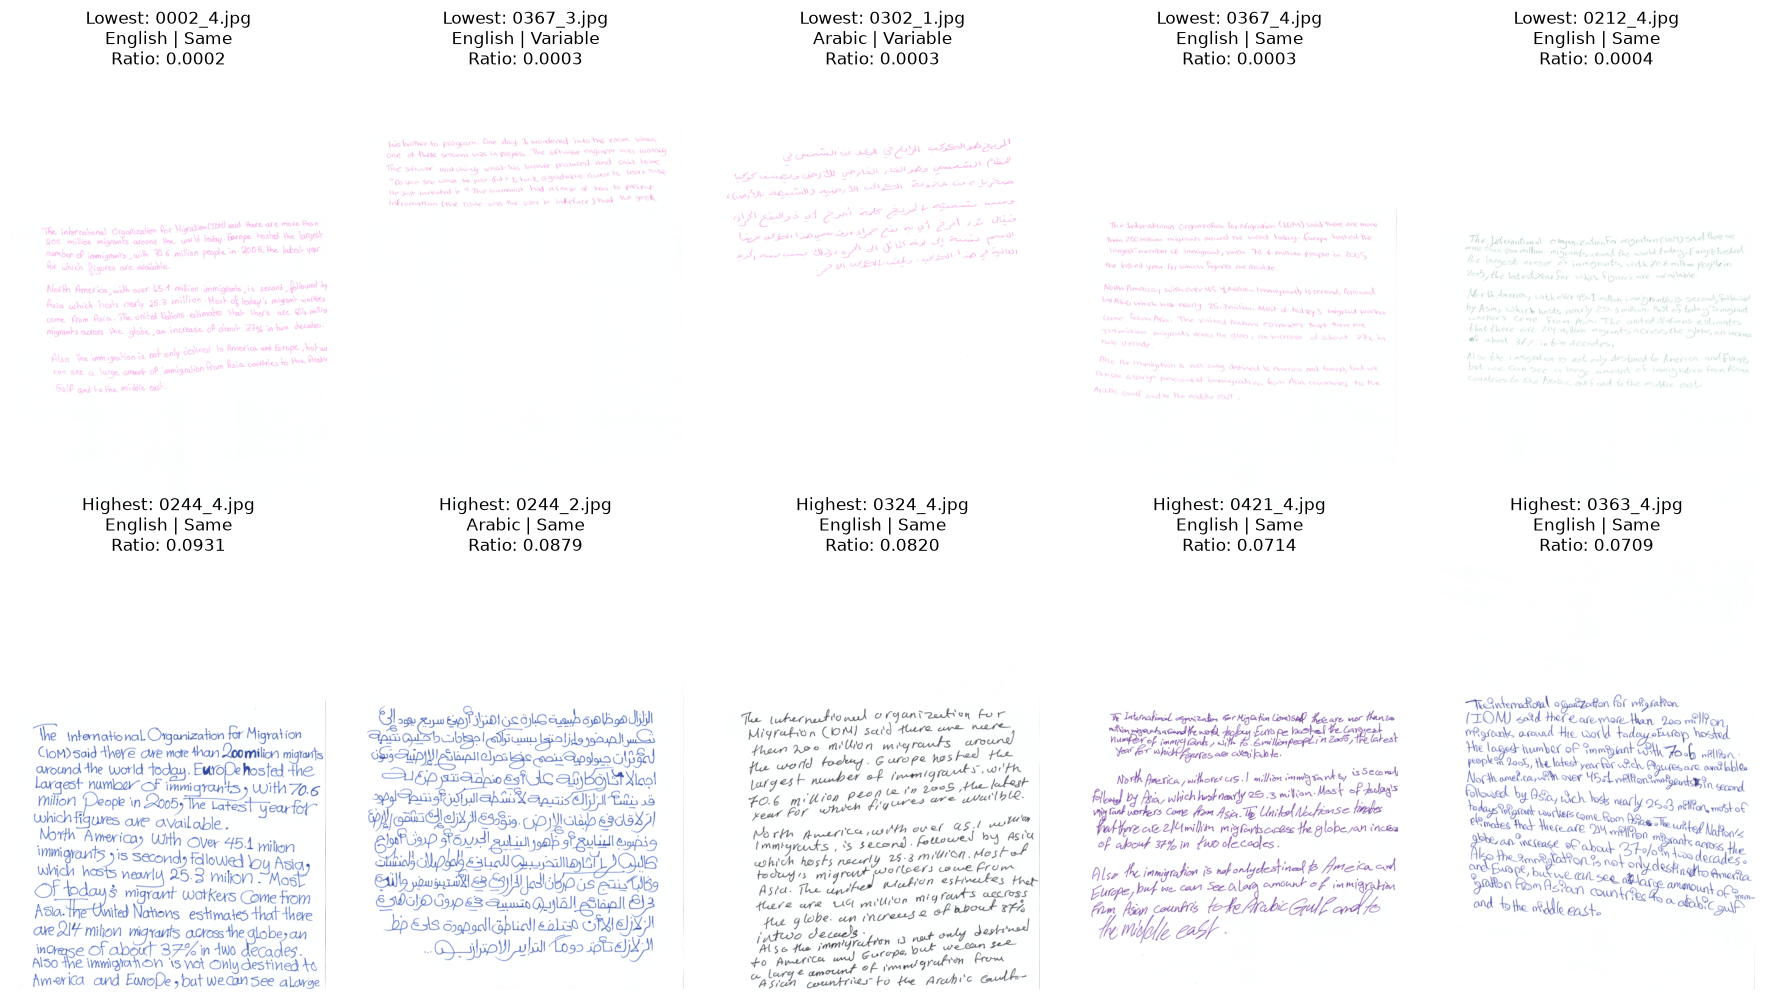

In [20]:
figure, axes = plt.subplots(2, 5, figsize=(18, 10))

for axis, row in zip(axes.flat, inspection_df.itertuples()):
    with Image.open(IMAGE_DIR / row.filename) as image:
        preview = image.copy()
        preview.thumbnail((700, 700))

    text_condition = "Same" if row.same_text == 1 else "Variable"

    axis.imshow(preview)
    axis.set_title(
        f"{row.density_group}: {row.filename}\n"
        f"{row.language} | {text_condition}\n"
        f"Ratio: {row.dark_pixel_ratio:.4f}"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [21]:
def estimate_color_foreground(
    image_path,
    max_size=512,
    distance_threshold=30,
):
    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB")
        rgb_image.thumbnail((max_size, max_size))
        pixels = np.asarray(rgb_image, dtype=np.float32)

    color_distance = np.sqrt(
        np.sum((255.0 - pixels) ** 2, axis=2)
    )

    return {
        "mean_color_distance": float(color_distance.mean()),
        "color_foreground_ratio": float(
            (color_distance > distance_threshold).mean()
        ),
    }


color_statistics = []

for filename in data_df["filename"]:
    statistics = estimate_color_foreground(IMAGE_DIR / filename)
    color_statistics.append(statistics)

color_statistics_df = pd.DataFrame(color_statistics)

data_df["mean_color_distance"] = (
    color_statistics_df["mean_color_distance"].values
)
data_df["color_foreground_ratio"] = (
    color_statistics_df["color_foreground_ratio"].values
)

print("Computed color statistics:", len(color_statistics_df))
print("Missing values:", int(color_statistics_df.isna().sum().sum()))

Computed color statistics: 1900
Missing values: 0


In [22]:
color_summary = (
    data_df.groupby(
        ["language", "same_text"],
        observed=True,
    )
    .agg(
        images=("filename", "size"),
        median_dark_pixel_ratio=("dark_pixel_ratio", "median"),
        median_color_foreground_ratio=("color_foreground_ratio", "median"),
        median_color_distance=("mean_color_distance", "median"),
    )
    .reset_index()
)

metric_correlation = data_df[
    [
        "dark_pixel_ratio",
        "color_foreground_ratio",
    ]
].corr().iloc[0, 1]

comparison_df = (
    data_df.nsmallest(10, "dark_pixel_ratio")[
        [
            "filename",
            "language",
            "same_text",
            "dark_pixel_ratio",
            "color_foreground_ratio",
            "mean_color_distance",
        ]
    ]
    .reset_index(drop=True)
)

print("Metric correlation:", round(metric_correlation, 4))
display(color_summary.round(4))
display(comparison_df.round(4))

Metric correlation: 0.8734


,language,same_text,images,median_dark_pixel_ratio,median_color_foreground_ratio,median_color_distance
0,Arabic,0,475,0.0117,0.0277,2.6648
1,Arabic,1,475,0.0190,0.0465,4.4184
2,English,0,475,0.0141,0.0293,3.1558
3,English,1,475,0.0273,0.0602,6.1250


,filename,language,same_text,dark_pixel_ratio,color_foreground_ratio,mean_color_distance
0,0002_4.jpg,English,1,0.0002,0.0397,2.9258
1,0367_3.jpg,English,0,0.0003,0.0157,1.3379
2,0302_1.jpg,Arabic,0,0.0003,0.0197,1.3286
3,0367_4.jpg,English,1,0.0003,0.0258,2.1673
4,0212_4.jpg,English,1,0.0004,0.0315,2.4206
5,0225_1.jpg,Arabic,0,0.0007,0.0159,1.1356
6,0039_3.jpg,English,0,0.0007,0.0156,1.0946
7,0160_1.jpg,Arabic,0,0.0010,0.0221,1.5281
8,0367_2.jpg,Arabic,1,0.0012,0.0257,1.8471
9,0410_1.jpg,Arabic,0,0.0018,0.0181,1.4230


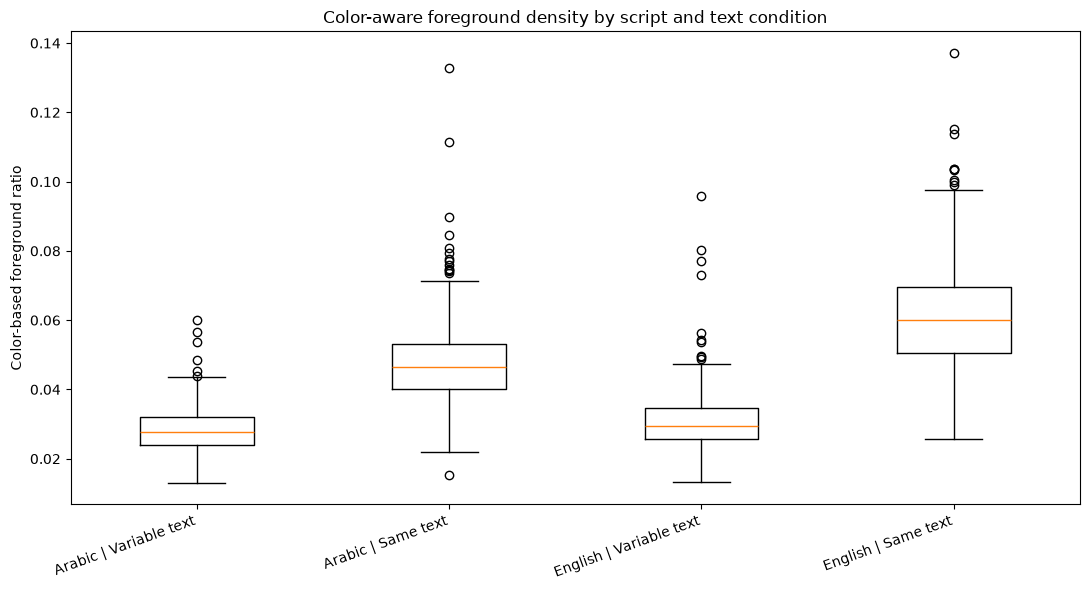

In [23]:
color_ratio_groups = [
    data_df.loc[
        data_df["condition"] == condition,
        "color_foreground_ratio",
    ]
    for condition in condition_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(
    color_ratio_groups,
    tick_labels=condition_order,
    showfliers=True,
)
plt.ylabel("Color-based foreground ratio")
plt.title("Color-aware foreground density by script and text condition")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [24]:
split_condition_summary = (
    data_df.groupby(
        [
            "experiment_split",
            "language",
            "same_text",
        ],
        observed=True,
    )
    .agg(
        images=("filename", "size"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median"),
        median_color_foreground_ratio=(
            "color_foreground_ratio",
            "median",
        ),
    )
    .reset_index()
)

display(split_condition_summary.round(4))

,experiment_split,language,same_text,images,median_aspect_ratio,median_file_size_kb,median_color_foreground_ratio
0,development_train,Arabic,0,226,0.7318,774.6704,0.0275
1,development_train,Arabic,1,226,0.7334,1182.2461,0.0465
2,development_train,English,0,226,0.7338,1100.4858,0.0290
3,development_train,English,1,226,0.7336,1626.6953,0.0595
4,official_test,Arabic,0,193,0.7322,743.7314,0.0277
5,official_test,Arabic,1,193,0.7330,1175.3379,0.0462
6,official_test,English,0,193,0.7335,1095.9482,0.0297
7,official_test,English,1,193,0.7338,1655.2676,0.0615
8,validation,Arabic,0,56,0.7317,751.1777,0.0280
9,validation,Arabic,1,56,0.7320,1263.1309,0.0453


In [25]:
writer_condition_df = (
    data_df.pivot(
        index="writer",
        columns="page_id",
        values="color_foreground_ratio",
    )
    .rename(
        columns={
            1: "arabic_variable",
            2: "arabic_same",
            3: "english_variable",
            4: "english_same",
        }
    )
    .reset_index()
)

writer_condition_df["arabic_same_minus_variable"] = (
    writer_condition_df["arabic_same"]
    - writer_condition_df["arabic_variable"]
)

writer_condition_df["english_same_minus_variable"] = (
    writer_condition_df["english_same"]
    - writer_condition_df["english_variable"]
)

writer_condition_df["english_minus_arabic_variable"] = (
    writer_condition_df["english_variable"]
    - writer_condition_df["arabic_variable"]
)

writer_condition_df["english_minus_arabic_same"] = (
    writer_condition_df["english_same"]
    - writer_condition_df["arabic_same"]
)

difference_columns = [
    "arabic_same_minus_variable",
    "english_same_minus_variable",
    "english_minus_arabic_variable",
    "english_minus_arabic_same",
]

paired_summary = (
    writer_condition_df[difference_columns]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .T
)

paired_summary["positive_writers"] = (
    writer_condition_df[difference_columns] > 0
).sum()

display(paired_summary.round(4))

,count,mean,median,std,min,max,positive_writers
page_id,,,,,,,
arabic_same_minus_variable,475.0,0.0191,0.0178,0.0106,-0.0183,0.1078,470
english_same_minus_variable,475.0,0.0301,0.0300,0.0127,-0.0277,0.0901,472
english_minus_arabic_variable,475.0,0.0024,0.0019,0.0079,-0.0283,0.0549,294
english_minus_arabic_same,475.0,0.0134,0.0134,0.0103,-0.0293,0.0473,433


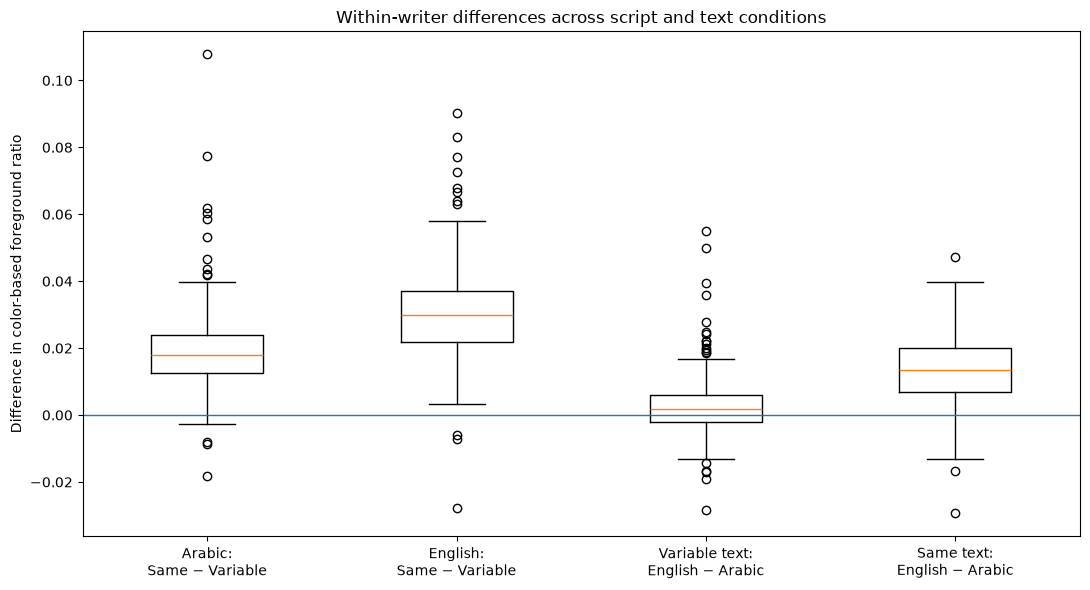

In [27]:
difference_labels = [
    "Arabic:\nSame − Variable",
    "English:\nSame − Variable",
    "Variable text:\nEnglish − Arabic",
    "Same text:\nEnglish − Arabic",
]

difference_values = [
    writer_condition_df[column]
    for column in difference_columns
]

plt.figure(figsize=(11, 6))
plt.boxplot(
    difference_values,
    tick_labels=difference_labels,
    showfliers=True,
)
plt.axhline(0, linewidth=1)
plt.ylabel("Difference in color-based foreground ratio")
plt.title("Within-writer differences across script and text conditions")
plt.tight_layout()
plt.show()

In [28]:
correlation_columns = [
    "width",
    "height",
    "aspect_ratio",
    "file_size_kb",
    "mean_intensity",
    "dark_pixel_ratio",
    "mean_color_distance",
    "color_foreground_ratio",
]

correlation_matrix = data_df[
    correlation_columns
].corr()

display(correlation_matrix.round(3))

,width,height,aspect_ratio,file_size_kb,mean_intensity,dark_pixel_ratio,mean_color_distance,color_foreground_ratio
width,1.000,0.781,-0.060,0.321,0.022,-0.020,-0.021,-0.021
height,0.781,1.000,-0.649,0.234,0.149,-0.143,-0.147,-0.134
aspect_ratio,-0.060,-0.649,1.000,-0.017,-0.193,0.184,0.191,0.171
file_size_kb,0.321,0.234,-0.017,1.000,-0.564,0.499,0.574,0.590
mean_intensity,0.022,0.149,-0.193,-0.564,1.000,-0.976,-0.994,-0.937
dark_pixel_ratio,-0.020,-0.143,0.184,0.499,-0.976,1.000,0.967,0.873
mean_color_distance,-0.021,-0.147,0.191,0.574,-0.994,0.967,1.000,0.931
color_foreground_ratio,-0.021,-0.134,0.171,0.590,-0.937,0.873,0.931,1.000


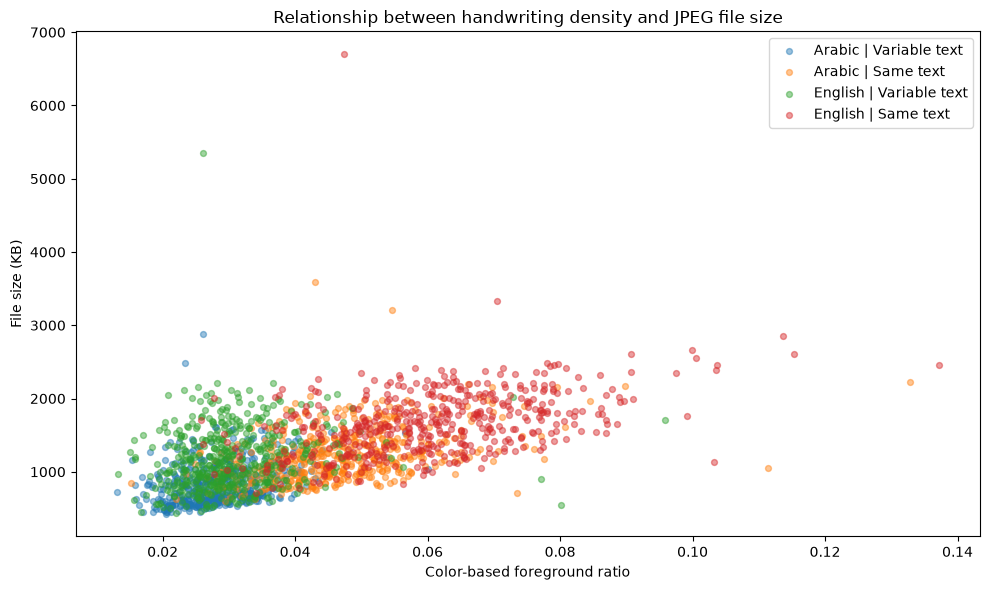

In [29]:
plt.figure(figsize=(10, 6))

for condition in condition_order:
    condition_df = data_df[
        data_df["condition"] == condition
    ]

    plt.scatter(
        condition_df["color_foreground_ratio"],
        condition_df["file_size_kb"],
        alpha=0.45,
        s=18,
        label=condition,
    )

plt.xlabel("Color-based foreground ratio")
plt.ylabel("File size (KB)")
plt.title("Relationship between handwriting density and JPEG file size")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
REPORT_DIR = PROJECT_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

eda_summary = {
    "dataset": "QUWI",
    "total_images": int(len(data_df)),
    "total_writers": int(data_df["writer"].nunique()),
    "language_counts": {
        key: int(value)
        for key, value in data_df["language"].value_counts().items()
    },
    "text_condition_counts": {
        str(key): int(value)
        for key, value in data_df["same_text"].value_counts().items()
    },
    "landscape_images": int((data_df["aspect_ratio"] >= 1).sum()),
    "median_aspect_ratio": float(data_df["aspect_ratio"].median()),
    "median_file_size_kb": float(data_df["file_size_kb"].median()),
    "dark_color_metric_correlation": float(metric_correlation),
    "file_size_color_foreground_correlation": float(
        correlation_matrix.loc[
            "file_size_kb",
            "color_foreground_ratio",
        ]
    ),
    "within_writer_results": {
        "arabic_same_greater_than_variable": int(
            (
                writer_condition_df[
                    "arabic_same_minus_variable"
                ]
                > 0
            ).sum()
        ),
        "english_same_greater_than_variable": int(
            (
                writer_condition_df[
                    "english_same_minus_variable"
                ]
                > 0
            ).sum()
        ),
        "english_same_greater_than_arabic_same": int(
            (
                writer_condition_df[
                    "english_minus_arabic_same"
                ]
                > 0
            ).sum()
        ),
    },
}

summary_path = REPORT_DIR / "quwi_eda_summary.json"

with summary_path.open("w", encoding="utf-8") as file:
    json.dump(eda_summary, file, indent=2)

print("Summary path:", summary_path)
print(json.dumps(eda_summary, indent=2))

Summary path: /home/arijit/Documents/handwriting-cross-script-research/reports/eda/quwi_eda_summary.json
{
  "dataset": "QUWI",
  "total_images": 1900,
  "total_writers": 475,
  "language_counts": {
    "Arabic": 950,
    "English": 950
  },
  "text_condition_counts": {
    "0": 950,
    "1": 950
  },
  "landscape_images": 11,
  "median_aspect_ratio": 0.733017,
  "median_file_size_kb": 1171.00048828125,
  "dark_color_metric_correlation": 0.87338093998548,
  "file_size_color_foreground_correlation": 0.5899342970283066,
  "within_writer_results": {
    "arabic_same_greater_than_variable": 470,
    "english_same_greater_than_variable": 472,
    "english_same_greater_than_arabic_same": 433
  }
}


In [31]:
condition_summary.to_csv(
    REPORT_DIR / "condition_image_summary.csv",
    index=False,
)

split_condition_summary.to_csv(
    REPORT_DIR / "split_condition_summary.csv",
    index=False,
)

extreme_aspect_ratio_df.to_csv(
    REPORT_DIR / "nonstandard_aspect_ratio_samples.csv",
    index=False,
)

paired_summary.reset_index(
    names="comparison"
).to_csv(
    REPORT_DIR / "within_writer_condition_differences.csv",
    index=False,
)

correlation_matrix.to_csv(
    REPORT_DIR / "image_feature_correlations.csv"
)

saved_files = sorted(
    path.name
    for path in REPORT_DIR.iterdir()
    if path.is_file()
)

print("Saved report files:", len(saved_files))

for filename in saved_files:
    print(filename)

Saved report files: 6
condition_image_summary.csv
image_feature_correlations.csv
nonstandard_aspect_ratio_samples.csv
quwi_eda_summary.json
split_condition_summary.csv
within_writer_condition_differences.csv


## EDA conclusions

The QUWI dataset is balanced across Arabic and English scripts, variable-text and same-text conditions, and the three writer-disjoint experiment splits.

Most images have a portrait aspect ratio near 0.73. Eleven valid images have nonstandard landscape or tightly cropped layouts, so preprocessing should preserve aspect ratio and use padding rather than forced stretching.

File size and foreground density vary systematically across script and text conditions. Same-text pages contain more foreground content than variable-text pages for nearly all writers:

- Arabic same-text density was higher for 470 of 475 writers.
- English same-text density was higher for 472 of 475 writers.
- English same-text density was higher than Arabic same-text density for 433 of 475 writers.

These differences indicate that page layout, handwriting amount, script, and text condition may provide nuisance cues to a writer-verification model. Later experiments must therefore measure and control script and content leakage.

The foreground-density measurements are approximate exploratory indicators. They must not be used alone to remove samples or make final preprocessing decisions.

In [32]:
report_tables = {
    "condition_image_summary.csv": pd.read_csv(
        REPORT_DIR / "condition_image_summary.csv"
    ),
    "split_condition_summary.csv": pd.read_csv(
        REPORT_DIR / "split_condition_summary.csv"
    ),
    "nonstandard_aspect_ratio_samples.csv": pd.read_csv(
        REPORT_DIR / "nonstandard_aspect_ratio_samples.csv"
    ),
    "within_writer_condition_differences.csv": pd.read_csv(
        REPORT_DIR / "within_writer_condition_differences.csv"
    ),
    "image_feature_correlations.csv": pd.read_csv(
        REPORT_DIR / "image_feature_correlations.csv",
        index_col=0,
    ),
}

for filename, table in report_tables.items():
    print(filename, table.shape)

with summary_path.open("r", encoding="utf-8") as file:
    saved_eda_summary = json.load(file)

print("Summary dataset:", saved_eda_summary["dataset"])
print("Summary images:", saved_eda_summary["total_images"])
print("Summary writers:", saved_eda_summary["total_writers"])

assert report_tables["condition_image_summary.csv"].shape == (4, 7)
assert report_tables["split_condition_summary.csv"].shape == (12, 7)
assert report_tables["nonstandard_aspect_ratio_samples.csv"].shape == (11, 9)
assert report_tables["within_writer_condition_differences.csv"].shape == (4, 8)
assert report_tables["image_feature_correlations.csv"].shape == (8, 8)
assert saved_eda_summary["total_images"] == 1900
assert saved_eda_summary["total_writers"] == 475

condition_image_summary.csv (4, 7)
split_condition_summary.csv (12, 7)
nonstandard_aspect_ratio_samples.csv (11, 9)
within_writer_condition_differences.csv (4, 8)
image_feature_correlations.csv (8, 8)
Summary dataset: QUWI
Summary images: 1900
Summary writers: 475
